In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("Teleco_Customer_Churn1.csv")

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0.0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0.0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,NaN,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,NaN,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,NaN,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     6274 non-null   float64
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       5113 non-null   object 
 13  StreamingTV       5632 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,6274.000000,7043.000000,7043.000000
mean,0.162894,32.371149,64.761692
std,0.369299,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,769
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Handling Missing Values

In [ ]:
df['SeniorCitizen'] = df['SeniorCitizen'].fillna(df['SeniorCitizen'].median())

df['TechSupport'] = df['TechSupport'].fillna(df['TechSupport'].mode()[0])

df['StreamingTV'] = df['StreamingTV'].fillna(df['StreamingTV'].mode()[0])

In [ ]:
df.replace("No internet service", "No", inplace=True)
df.replace("No phone service", "No", inplace=True)

In [ ]:
yes_no_cols = ['Partner','Dependents','PhoneService','PaperlessBilling','Churn']

for col in yes_no_cols:
    df[col] = df[col].map({'Yes':1, 'No':0})

In [ ]:
df['gender'] = df['gender'].map({'Male':1, 'Female':0})

In [ ]:
df.drop("customerID", axis=1, inplace=True)

In [ ]:
df = pd.get_dummies(df)

In [ ]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [ ]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
PaperlessBilling,0
MonthlyCharges,0
TotalCharges,0
Churn,0


In [ ]:
df.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.504756,0.145109,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2281.916928,0.265370
std,0.500013,0.352235,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2265.270398,0.441561
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,402.225000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3786.600000,1.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,1.000000


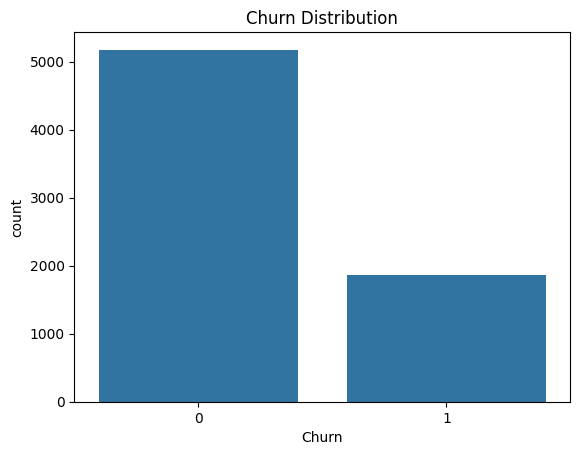

In [ ]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

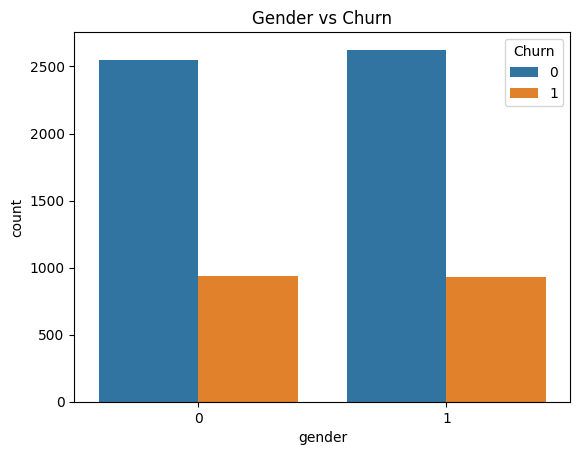

In [ ]:
sns.countplot(x="gender", hue="Churn", data=df)
plt.title("Gender vs Churn")
plt.show()

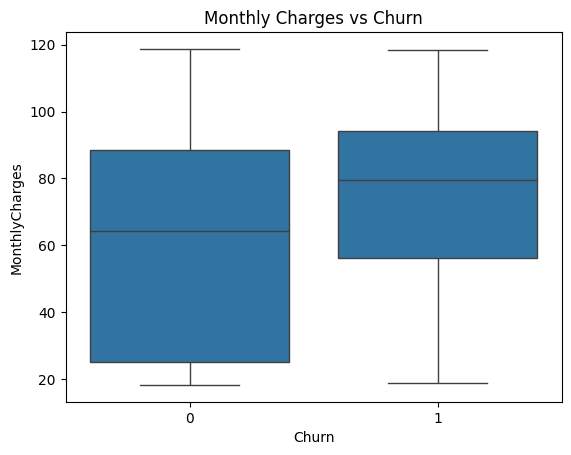

In [ ]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

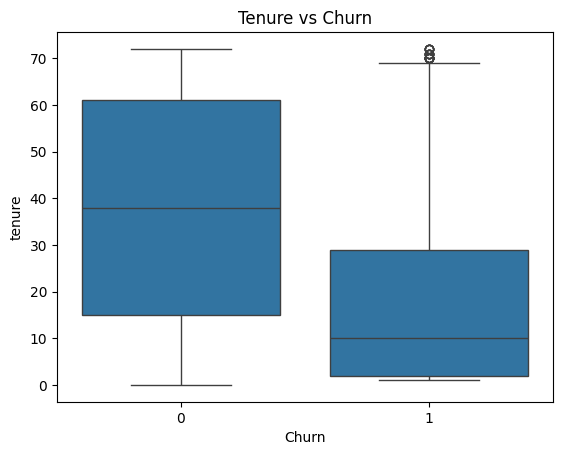

In [ ]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

A correlation heatmap was used to identify relationships between features. It showed that tenure and contract type have strong influence on churn, while some categorical features show expected inverse correlations due to one-hot encoding.

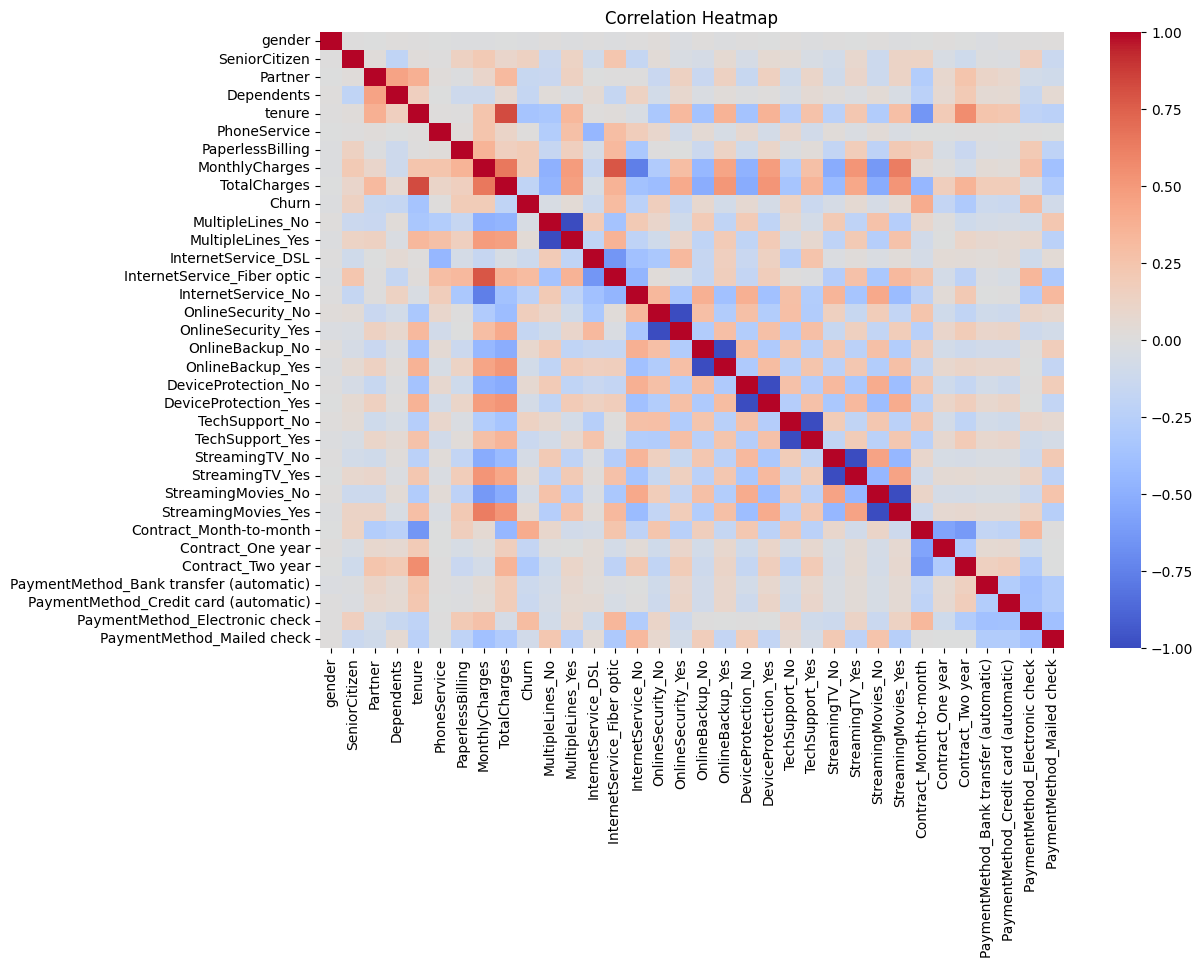

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

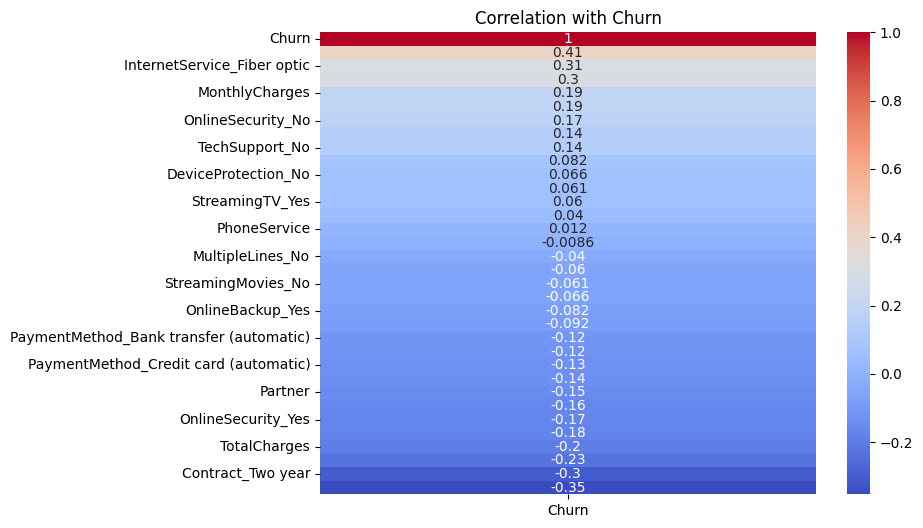

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr()[['Churn']].sort_values(by='Churn', ascending=False),
            annot=True, cmap="coolwarm")
plt.title("Correlation with Churn")
plt.show()

In [ ]:
df.corr()['Churn'].sort_values(ascending=False)

,Churn
Churn,1.000000
Contract_Month-to-month,0.405103
InternetService_Fiber optic,0.308020
PaymentMethod_Electronic check,0.301919
MonthlyCharges,0.193356
PaperlessBilling,0.191825
OnlineSecurity_No,0.171226
SeniorCitizen,0.141328
TechSupport_No,0.139512
OnlineBackup_No,0.082255


In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8197303051809794
[[932 104]
 [150 223]]
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



In [ ]:
from sklearn.metrics import accuracy_score

lr_acc = accuracy_score(y_test, y_pred)
print("Logistic Accuracy:", lr_acc)

Logistic Accuracy: 0.8197303051809794


Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.7466288147622427


Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

Model Evaluation
🔹 Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

print("Logistic:\n", confusion_matrix(y_test, y_pred))
print("Decision Tree:\n", confusion_matrix(y_test, dt_pred))
print("Random Forest:\n", confusion_matrix(y_test, rf_pred))

Logistic:
 [[932 104]
 [150 223]]
Decision Tree:
 [[852 184]
 [173 200]]
Random Forest:
 [[951  85]
 [191 182]]


Model Comparison
* Logistic Regression (BEST BALANCE)

Good TP (223)

FN lower than RF

Balanced performance

 Best for detecting churn customers


*Decision Tree

More errors

Overfitting issue


 *Weak model

 Random Forest
Best TN (951)  → predicts non-churn well
But FN = 191  → misses many churn customers

 Good overall accuracy but misses churn cases

In [ ]:
from sklearn.metrics import classification_report

print("Logistic Regression:\n", classification_report(y_test, y_pred))
print("Decision Tree:\n", classification_report(y_test, dt_pred))
print("Random Forest:\n", classification_report(y_test, rf_pred))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409

Decision Tree:
               precision    recall  f1-score   support

           0       0.83      0.82      0.83      1036
           1       0.52      0.54      0.53       373

    accuracy                           0.75      1409
   macro avg       0.68      0.68      0.68      1409
weighted avg       0.75      0.75      0.75      1409

Random Forest:
               precision    recall  f1-score   support

           0       0.83      0.92      0.87      1036
           1       0.68      0.49      0.57       373

    accuracy                           0.80      1409
   macro avg       0.76      0.70      0.72      1409
weighted avg       0

In [ ]:
from sklearn.metrics import roc_auc_score

print("Logistic AUC:", roc_auc_score(y_test, y_pred))
print("Decision Tree AUC:", roc_auc_score(y_test, dt_pred))
print("Random Forest AUC:", roc_auc_score(y_test, rf_pred))

Logistic AUC: 0.7487345637479685
Decision Tree AUC: 0.6792934259422195
Random Forest AUC: 0.7029446623950645


In [ ]:
import joblib

joblib.dump(model, "churn_model.pkl")

['churn_model.pkl']

In [ ]:
from google.colab import files
files.download("churn_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.to_csv("churn_clean.csv", index=False)

In [ ]:
from google.colab import files
files.download("churn_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.to_csv("churn_clean.csv", index=False, encoding='utf-8')
from google.colab import files
files.download("churn_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>